# Daylan+2017 Fermi-LAT point-source analysis

Run PCAT on an explicitly simulated Fermi-LAT-like field and inspect posterior source catalogs, source counts, likelihood evolution, and reconstructed count maps. The archival Fermi inputs used in the paper are not distributed here, so these figures are synthetic demonstrations of the published analysis method, not reproductions of its measured data or numerical results.

In [1]:
from pcat.demo import load_example_namespace

example = load_example_namespace(
    'daylan+2017_fermi_point_sources/daylan+2017_fermi_point_sources.py'
)
run = example['run_reproduction'](smoke=True)
posterior = example['read_posterior'](run)


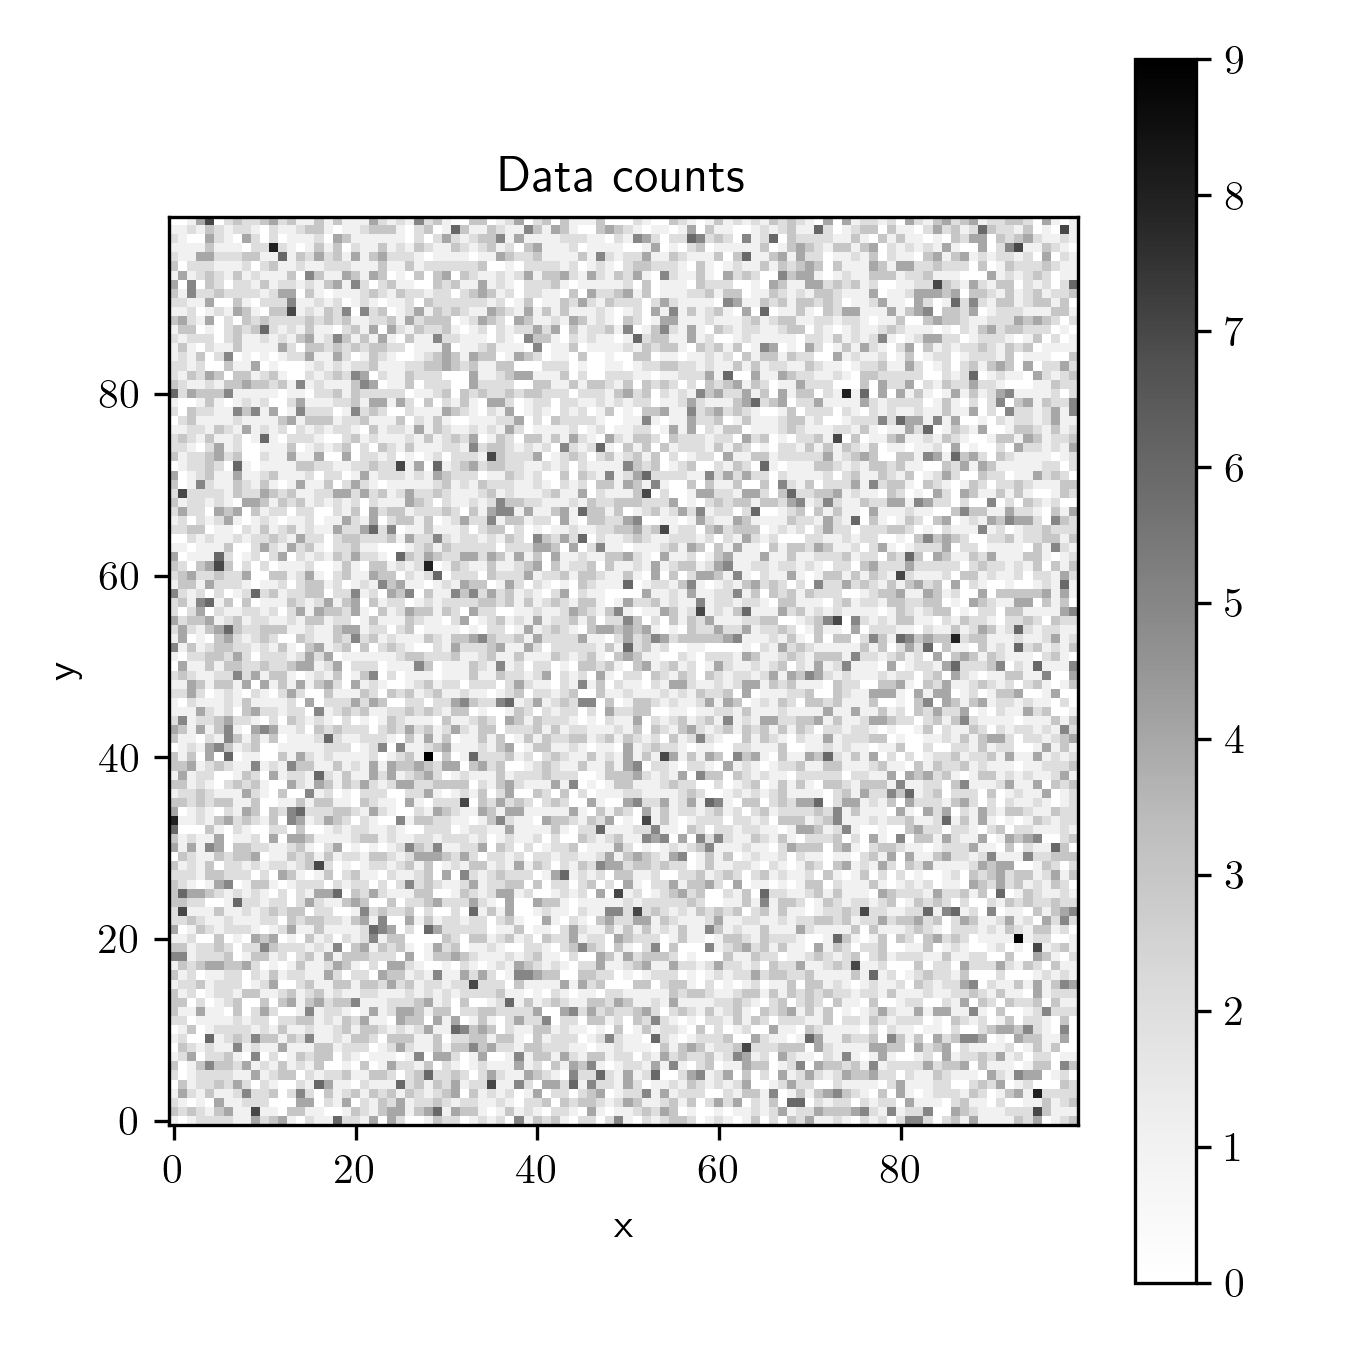

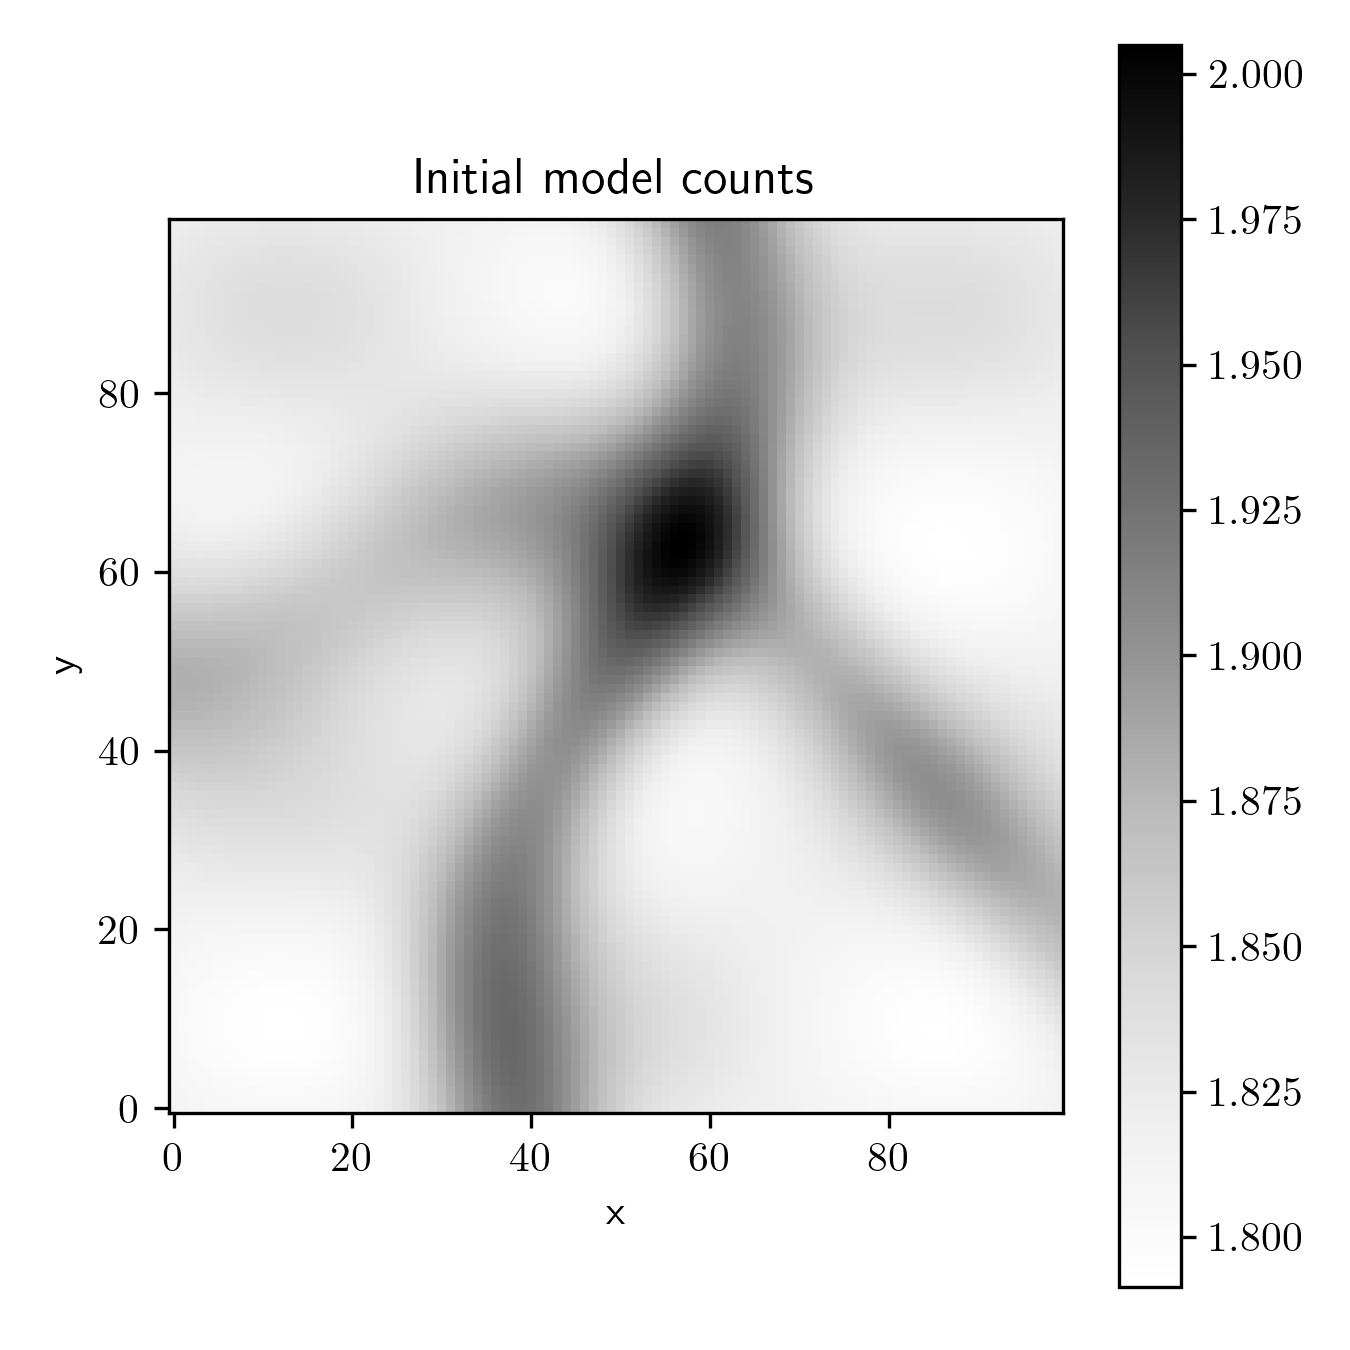

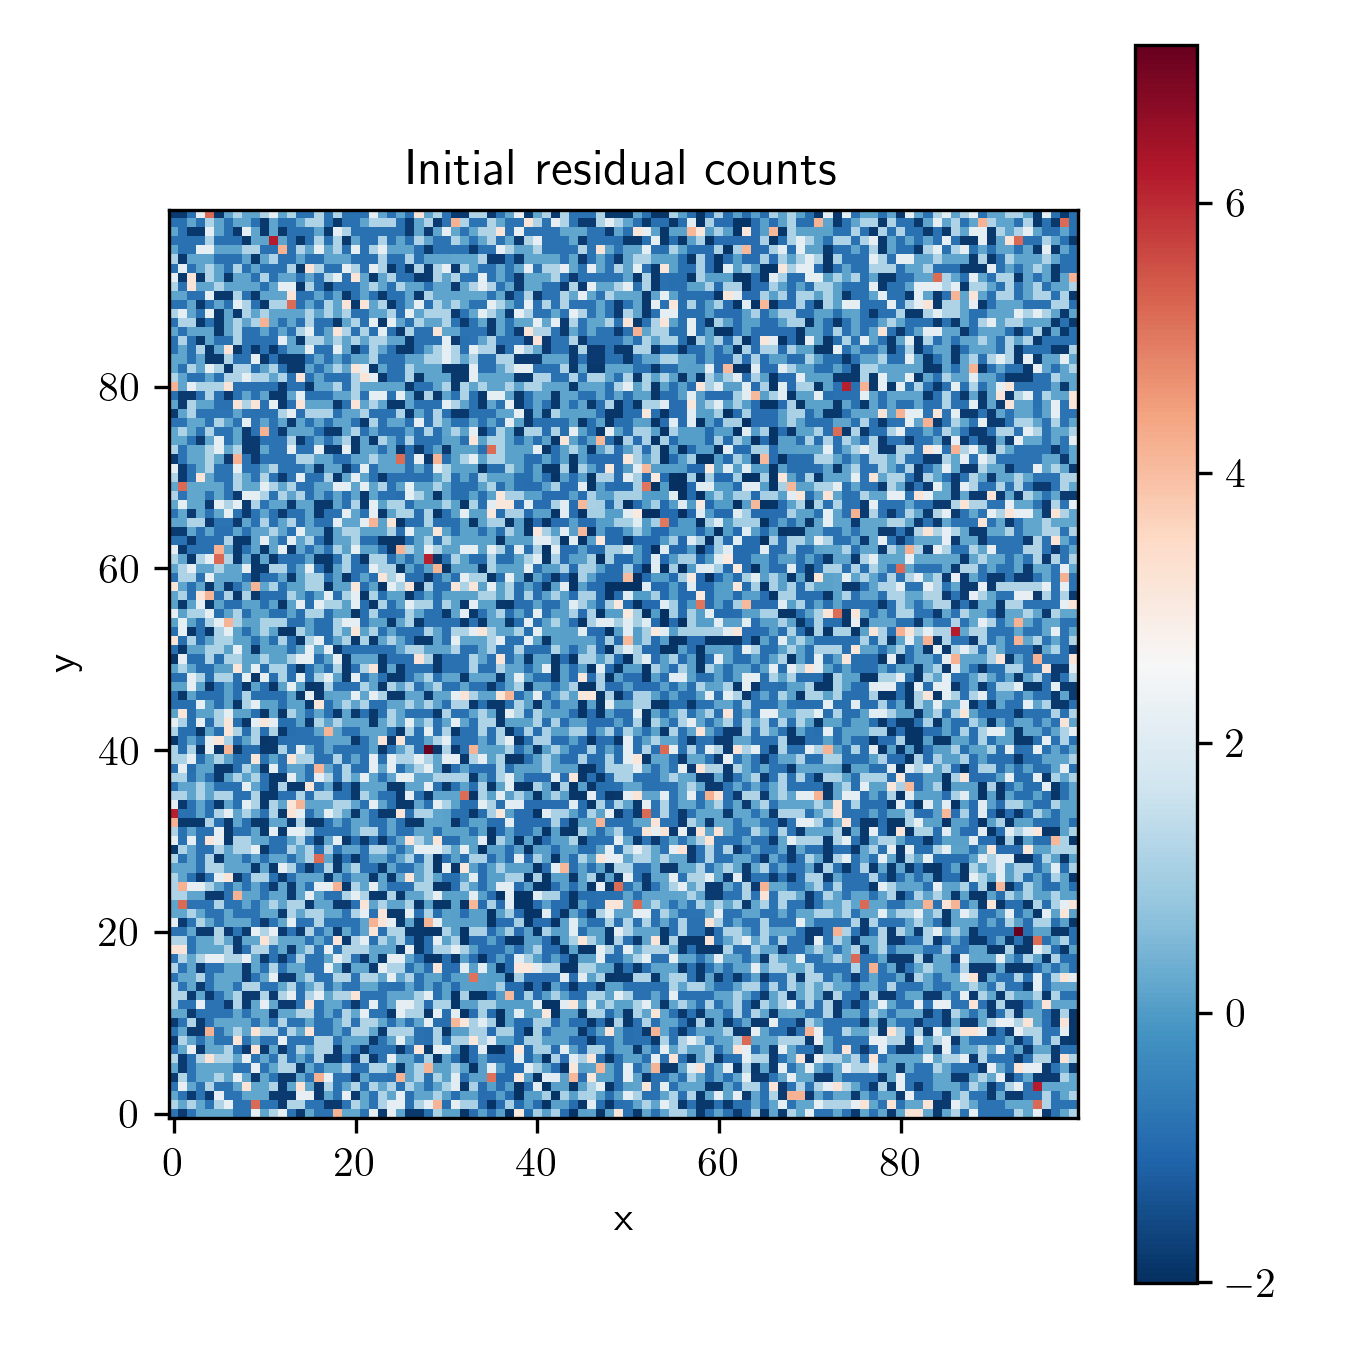

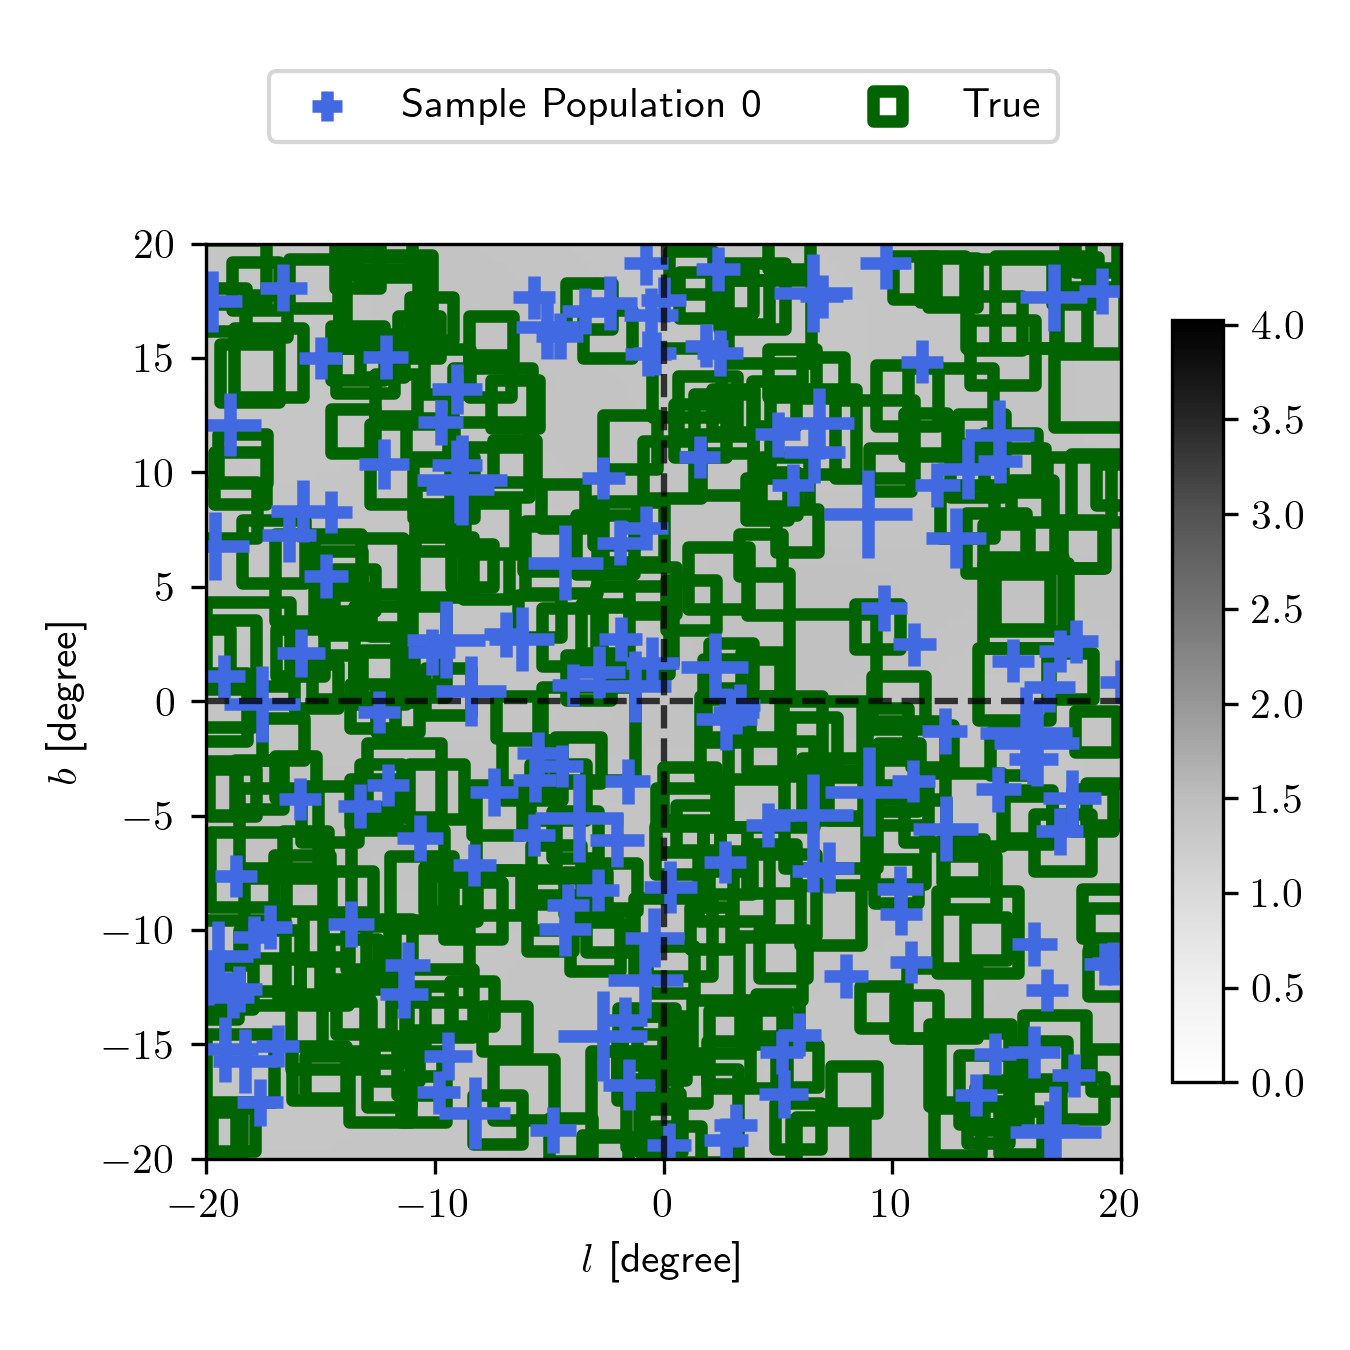

In [2]:
from pcat.demo import display_example_visuals

display_example_visuals(
    'daylan+2017_fermi_point_sources',
    'visuals/init/datacountsen00evt0.png',
    'visuals/init/cntpmodlen00evt0.png',
    'visuals/init/cntpresien00evt0.png',
    'visuals/post/fram/thiscntpmodlen00evt0_*.png',
)


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from tdpy.verbosity import print

plt.rcParams.update({
    'font.size': 10,
    'text.usetex': False,
    'axes.grid': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
})

visuals_path = Path(example['OUTPUT_ROOT']) / 'visuals'
visuals_path.mkdir(parents=True, exist_ok=True)
number_side = int(np.sqrt(posterior.cntpdata.shape[1]))
half_width_deg = example['FIELD_HALF_WIDTH_DEG']
radian_to_degree = np.rad2deg(1.0)  # [deg rad^-1]


def save_and_show(figure, filename):
    path = visuals_path / filename
    print(f'Writing to {path}...')
    figure.savefig(path, dpi=300, bbox_inches='tight')
    display(figure)
    plt.close(figure)


# Compare the observed image with posterior model and residual maps.
data_map = posterior.cntpdata[0, :, 0].reshape(number_side, number_side)
model_samples = posterior.listpostcntpmodl[:, 0, :, 0].reshape(
    -1, number_side, number_side
)
model_median = np.percentile(model_samples, 50, axis=0)
standardized_residual = (data_map - model_median) / np.sqrt(
    np.maximum(model_median, 1.0)
)
residual_limit = np.percentile(np.abs(standardized_residual), 99)
extent = (-half_width_deg, half_width_deg, -half_width_deg, half_width_deg)
figure, axes = plt.subplots(1, 3, figsize=(10.5, 3.4), constrained_layout=True)
for axis, image, title in zip(
    axes[:2],
    (data_map, model_median),
    ('Simulated data', 'Posterior median model'),
):
    artist = axis.imshow(image, origin='lower', extent=extent, cmap='magma')
    axis.set_title(title)
    axis.set_xlabel('Angular offset theta_1 [deg]')
    axis.set_ylabel('Angular offset theta_2 [deg]')
    figure.colorbar(artist, ax=axis, label='Counts per pixel')
artist = axes[2].imshow(
    standardized_residual,
    origin='lower',
    extent=extent,
    cmap='coolwarm',
    vmin=-residual_limit,
    vmax=residual_limit,
)
axes[2].set_title('Posterior residual')
axes[2].set_xlabel('Angular offset theta_1 [deg]')
axes[2].set_ylabel('Angular offset theta_2 [deg]')
figure.colorbar(artist, ax=axes[2], label='Residual [model standard deviations]')
save_and_show(figure, 'fermi_posterior_count_maps.png')

# Combine source positions and fluxes over retained posterior catalogs.
list_catalog = posterior.listpostdictelem
list_flux = np.concatenate([np.asarray(catalog[0]['flux']) for catalog in list_catalog])
list_xpos_deg = np.concatenate(
    [np.asarray(catalog[0]['xpos']) for catalog in list_catalog]
) * radian_to_degree
list_ypos_deg = np.concatenate(
    [np.asarray(catalog[0]['ypos']) for catalog in list_catalog]
) * radian_to_degree
figure, axis = plt.subplots(figsize=(6.0, 5.0), constrained_layout=True)
artist = axis.scatter(
    list_xpos_deg,
    list_ypos_deg,
    c=np.log10(np.maximum(list_flux, np.finfo(float).tiny)),
    s=5,
    alpha=0.25,
    cmap='viridis',
    linewidths=0,
)
axis.set_xlim(-half_width_deg, half_width_deg)
axis.set_ylim(-half_width_deg, half_width_deg)
axis.set_aspect('equal')
axis.set_xlabel('Angular offset theta_1 [deg]')
axis.set_ylabel('Angular offset theta_2 [deg]')
figure.colorbar(artist, ax=axis, label=r'Log photon flux [ph cm$^{-2}$ s$^{-1}$]')
save_and_show(figure, 'fermi_posterior_source_catalog.png')

# Summarize the transdimensional source-count posterior and likelihood evolution.
source_count = np.asarray(posterior.listpostnumbelem).ravel().astype(int)
count_values, count_frequency = np.unique(source_count, return_counts=True)
figure, axis = plt.subplots(figsize=(5.2, 3.6), constrained_layout=True)
axis.bar(count_values, count_frequency / count_frequency.sum(), color='C0')
axis.axvline(
    example['build_configuration'](smoke=True)['truenumbelempop0'],
    color='C3',
    linestyle='--',
    label='Simulated input',
)
axis.set_xlabel('Number of point sources')
axis.set_ylabel('Posterior probability')
axis.legend(loc='best')
save_and_show(figure, 'fermi_posterior_source_count.png')

log_likelihood = np.asarray(posterior.listpostlliktotl).ravel()
figure, axis = plt.subplots(figsize=(7.0, 3.2), constrained_layout=True)
axis.plot(np.arange(log_likelihood.size), log_likelihood, color='C0', linewidth=0.8)
axis.set_xlabel('Retained posterior sample')
axis.set_ylabel('Log likelihood')
save_and_show(figure, 'fermi_posterior_log_likelihood.png')

<Figure size 2100x680 with 6 Axes>

<Figure size 1200x1000 with 2 Axes>

<Figure size 1040x720 with 1 Axes>

<Figure size 1400x640 with 1 Axes>